In [326]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [327]:
iris_dataset=pd.read_csv("diabetes2.csv")

In [328]:
iris_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [329]:
iris_dataset.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [330]:
for x in ['BloodPressure']:
    q75,q25 = np.percentile(iris_dataset.loc[:,x],[75,25])
    intr_qr = q75-q25
 
    max = q75+(1.5*intr_qr)
    min = q25-(1.5*intr_qr)
 
    iris_dataset.loc[iris_dataset[x] < min,x] = np.nan
    iris_dataset.loc[iris_dataset[x] > max,x] = np.nan
    
for x in ['Glucose']:
    q75,q25 = np.percentile(iris_dataset.loc[:,x],[75,25])
    intr_qr = q75-q25
 
    max = q75+(1.5*intr_qr)
    min = q25-(1.5*intr_qr)
 
    iris_dataset.loc[iris_dataset[x] < min,x] = np.nan
    iris_dataset.loc[iris_dataset[x] > max,x] = np.nan
    
for x in ['SkinThickness']:
    q75,q25 = np.percentile(iris_dataset.loc[:,x],[75,25])
    intr_qr = q75-q25
 
    max = q75+(1.5*intr_qr)
    min = q25-(1.5*intr_qr)
 
    iris_dataset.loc[iris_dataset[x] < min,x] = np.nan
    iris_dataset.loc[iris_dataset[x] > max,x] = np.nan
    
for x in ['Insulin']:
    q75,q25 = np.percentile(iris_dataset.loc[:,x],[75,25])
    intr_qr = q75-q25
 
    max = q75+(1.5*intr_qr)
    min = q25-(1.5*intr_qr)
 
    iris_dataset.loc[iris_dataset[x] < min,x] = np.nan
    iris_dataset.loc[iris_dataset[x] > max,x] = np.nan

In [331]:
iris_dataset.isnull().sum()

Pregnancies                  0
Glucose                      5
BloodPressure               45
SkinThickness                1
Insulin                     34
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

In [332]:
iris_dataset = iris_dataset.dropna(axis = 0)

In [333]:
iris_dataset.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [334]:
iris_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 683 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               683 non-null    int64  
 1   Glucose                   683 non-null    float64
 2   BloodPressure             683 non-null    float64
 3   SkinThickness             683 non-null    float64
 4   Insulin                   683 non-null    float64
 5   BMI                       683 non-null    float64
 6   DiabetesPedigreeFunction  683 non-null    float64
 7   Age                       683 non-null    int64  
 8   Outcome                   683 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 53.4 KB


In [335]:
iris_dataset.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [336]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(fill_value=np.nan, strategy='mean')
X = imputer.fit_transform(iris_dataset)

In [337]:
X = pd.DataFrame(X, columns=iris_dataset.columns)
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6.0    148.0           72.0           35.0      0.0  33.6   
1            1.0     85.0           66.0           29.0      0.0  26.6   
2            8.0    183.0           64.0            0.0      0.0  23.3   
3            1.0     89.0           66.0           23.0     94.0  28.1   
4            0.0    137.0           40.0           35.0    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
678         10.0    101.0           76.0           48.0    180.0  32.9   
679          2.0    122.0           70.0           27.0      0.0  36.8   
680          5.0    121.0           72.0           23.0    112.0  26.2   
681          1.0    126.0           60.0            0.0      0.0  30.1   
682          1.0     93.0           70.0           31.0      0.0  30.4   

     DiabetesPedigreeFunction   Age  Outcome  
0                       0.627  50.0      1.0  
1                

In [338]:
X.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

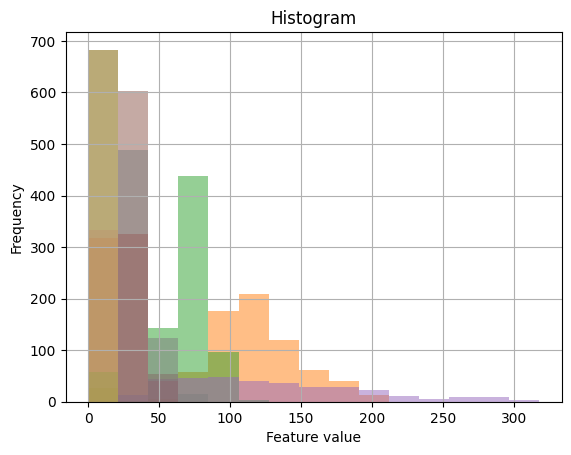

In [339]:
df = pd.DataFrame(X) # Create a pandas DataFrame out of the numpy array
df.plot.hist(alpha=0.5, bins=15, grid=True, legend=None)  # Pandas helper function to plot a hist. Uses matplotlib under the hood.
plt.xlabel("Feature value")
plt.title("Histogram")
plt.show()

In [340]:
iris_dataset.var(ddof=0)

Pregnancies                   11.334973
Glucose                      879.872897
BloodPressure                130.940995
SkinThickness                238.245704
Insulin                     6390.344977
BMI                           50.129183
DiabetesPedigreeFunction       0.106800
Age                          137.501000
Outcome                        0.220906
dtype: float64

In [341]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
iris_dataset.iloc[:,1:-1] = ss.fit_transform(iris_dataset.iloc[:,1:-1])
print(iris_dataset)

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0              6  0.947058      -0.024183       0.927032 -0.826923  0.224680   
1              1 -1.176825      -0.548523       0.538310 -0.826923 -0.763993   
2              8  2.126993      -0.723303      -1.340511 -0.826923 -1.230082   
3              1 -1.041976      -0.548523       0.149589  0.348964 -0.552135   
4              0  0.576221      -2.820665       0.927032  1.274662  1.566450   
..           ...       ...            ...            ...       ...       ...   
763           10 -0.637426       0.325378       1.769262  1.424776  0.125812   
764            2  0.070534      -0.198963       0.408736 -0.826923  0.676644   
765            5  0.036822      -0.024183       0.149589  0.574134 -0.820489   
766            1  0.205384      -1.072864      -1.340511 -0.826923 -0.269657   
767            1 -0.907126      -0.198963       0.667884 -0.826923 -0.227285   

     DiabetesPedigreeFunction       Age

In [342]:
iris_dataset.var(ddof=0)

Pregnancies                 11.334973
Glucose                      1.000000
BloodPressure                1.000000
SkinThickness                1.000000
Insulin                      1.000000
BMI                          1.000000
DiabetesPedigreeFunction     1.000000
Age                          1.000000
Outcome                      0.220906
dtype: float64

In [343]:
from sklearn.preprocessing import Normalizer

norm = Normalizer()
iris_dataset.iloc[:,1:-1] = norm.fit_transform(iris_dataset.iloc[:,1:-1])
iris_dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,0.434273,-0.011089,0.425090,-0.379185,0.103027,0.216835,0.655110,1
1,1,-0.636546,-0.296697,0.291173,-0.447284,-0.413245,-0.201039,-0.103670,0
2,8,0.692819,-0.235599,-0.436640,-0.269351,-0.400671,0.198879,-0.034651,1
3,1,-0.534510,-0.281380,0.076736,0.179011,-0.283233,-0.479483,-0.535785,0
4,0,0.086780,-0.424799,0.139613,0.191967,0.235911,0.836664,-0.003178,1
...,...,...,...,...,...,...,...,...,...
763,10,-0.176946,0.090323,0.491138,0.395510,0.034925,-0.256071,0.704340,0
764,2,0.052552,-0.148239,0.304533,-0.616108,0.504141,-0.301998,-0.396954,0
765,5,0.029217,-0.019188,0.118695,0.455561,-0.651038,-0.552282,-0.219746,0
766,1,0.089510,-0.467571,-0.584216,-0.360387,-0.117521,-0.164649,0.511133,1


In [344]:
x= iris_dataset.iloc[:,:8].values
y= iris_dataset['Outcome']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x , y , test_size = 0.25, random_state=82)

In [345]:
from sklearn.preprocessing import StandardScaler
 
object= StandardScaler()
 
x_train=object.fit_transform(x_train)
x_test=object.transform(x_test)

In [346]:
x_train

array([[ 0.66817796, -0.45943729,  0.04187098, ...,  0.82764581,
        -0.37067869,  1.89309611],
       [ 0.66817796,  0.18546053,  0.04160424, ...,  0.26098441,
         0.99515323,  0.18046156],
       [ 0.0658767 ,  0.43157738,  1.07947179, ..., -0.45840975,
        -0.03645038,  2.28129323],
       ...,
       [-0.83757519, -1.28086837, -0.23305108, ..., -0.31472466,
        -0.70159323, -1.19996753],
       [ 1.27047922,  0.08727796,  0.46534028, ..., -0.78312734,
        -0.05595519,  2.23434336],
       [ 0.36702733,  0.78984783,  0.44881541, ...,  0.22736177,
        -0.56056808,  2.21300597]])

In [347]:
x_test

array([[-0.23527393, -0.11705086,  0.29427828, ..., -1.23431252,
        -1.82247011, -1.09228646],
       [-0.83757519, -1.10534714,  0.02218559, ..., -1.6924984 ,
         1.26378496, -0.67682324],
       [-0.83757519,  0.3897177 ,  1.00941711, ..., -0.69538528,
        -1.2658435 , -0.95600978],
       ...,
       [-0.23527393, -1.29040239, -1.81965216, ..., -0.10528526,
        -0.63711313, -0.48447942],
       [-1.13872582,  0.21040342,  1.71162269, ...,  0.59671956,
        -1.03111893, -0.31906256],
       [-0.83757519, -0.96130474, -1.64017231, ..., -1.02527771,
        -0.76725011, -0.82161302]])

In [348]:
from sklearn.linear_model import LogisticRegression
logisticRegr = LogisticRegression(random_state =  82)
logisticRegr.fit(x_train , y_train)

LogisticRegression(random_state=82)

In [349]:
y_pred = logisticRegr.predict(x_test)
print(y_pred)

[0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 1 0
 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1
 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]


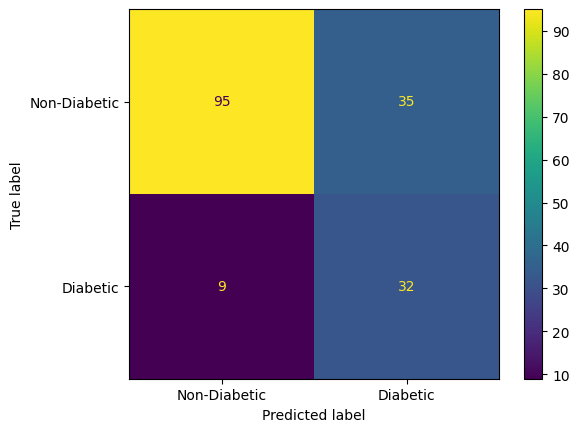

In [350]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics


confusion_matrix = metrics.confusion_matrix(y_pred, y_test)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['Non-Diabetic', 'Diabetic'])

cm_display.plot()
plt.show()

In [351]:
from sklearn.metrics import accuracy_score
print("Accuracy:" , accuracy_score(y_pred,y_test))

Accuracy: 0.7426900584795322


In [352]:
from sklearn.metrics import precision_score, recall_score, f1_score
print("Recall:" , recall_score(y_test, y_pred,average='macro'))

Recall: 0.6955367393800229


In [353]:
print("Precision: " , precision_score(y_test, y_pred,average='macro'))

Precision:  0.7556285178236397


In [354]:
print("F1 Score: ", f1_score(y_test, y_pred,average='macro'))

F1 Score:  0.7022792022792022
